In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/My Drive/archive.zip'
print("--- 🚀 Unzipping dataset... ---")
!unzip -q "{zip_path}" -d /content/dataset/
print("--- ✅ Unzipping complete! ---")

Mounted at /content/drive
--- 🚀 Unzipping dataset... ---
--- ✅ Unzipping complete! ---


In [ ]:
import pandas as pd

# FIX: Added '/dataset/' to the paths to match where you just unzipped them!
path_gt = '/content/dataset/ISIC_2019_Training_GroundTruth.csv'
path_meta = '/content/dataset/ISIC_2019_Training_Metadata.csv'

# Let's find out which file holds the patient secrets!
if os.path.exists(path_meta):
    print("✅ Found a separate Metadata file! Loading it...\n")
    df = pd.read_csv(path_meta)
elif os.path.exists(path_gt):
    print("✅ Loading Ground Truth file to check for patient data...\n")
    df = pd.read_csv(path_gt)
else:
    print("❌ ERROR: I cannot find the CSV files. Did you upload them to Colab?")
    df = None

if df is not None:
    print("🔍 --- EXACT COLUMNS IN THIS DATASET ---")
    print(df.columns.tolist())

    print("\n👀 --- SNEAK PEEK AT THE DATA (First 3 rows) ---")
    display(df.head(3))

    print("\n⚠️ --- MISSING VALUE CHECK (NaNs) ---")
    print(df.isnull().sum())

✅ Found a separate Metadata file! Loading it...

🔍 --- EXACT COLUMNS IN THIS DATASET ---
['image', 'age_approx', 'anatom_site_general', 'lesion_id', 'sex']

👀 --- SNEAK PEEK AT THE DATA (First 3 rows) ---


,image,age_approx,anatom_site_general,lesion_id,sex
0,ISIC_0000000,55.0,anterior torso,NaN,female
1,ISIC_0000001,30.0,anterior torso,NaN,female
2,ISIC_0000002,60.0,upper extremity,NaN,female



⚠️ --- MISSING VALUE CHECK (NaNs) ---
image                     0
age_approx              437
anatom_site_general    2631
lesion_id              2084
sex                     384
dtype: int64


In [ ]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import tensorflow as tf

# --- 1. DEFINE PATHS & LOAD DATA ---
base_dir = Path('/content/dataset/')
path_gt = base_dir / 'ISIC_2019_Training_GroundTruth.csv'
path_meta = base_dir / 'ISIC_2019_Training_Metadata.csv'

# Load Ground Truth and Metadata
df_gt = pd.read_csv(path_gt)

# Merge them so every image matches its patient data
if os.path.exists(path_meta):
    df_meta = pd.read_csv(path_meta)
    df = pd.merge(df_gt, df_meta, on='image', how='inner')
else:
    df = df_gt.copy()

# Filter for the 4 specific diseases
selected_lesions = {
    'MEL': 'Melanoma',
    'BCC': 'Basal cell carcinoma',
    'NV': 'Melanocytic nevi',
    'BKL': 'Benign keratosis',
}
df['label'] = df.iloc[:, 1:9].idxmax(axis=1)
df = df[df['label'].isin(selected_lesions.keys())].copy()
df['lesion_type'] = df['label'].map(selected_lesions)

# Map exact image paths
def create_correct_path(row):
    return os.path.join(base_dir, row['label'], row['image'] + '.jpg')
df['image_path'] = df.apply(create_correct_path, axis=1)

# --- 2. DATA CLEANING & IMPUTATION ---
print("--- 🧹 Cleaning Missing Values ---")
# Age: Fill with median and scale it
df['age_approx'] = df['age_approx'].fillna(df['age_approx'].median())
df['age_scaled'] = df['age_approx'] / 100.0

# Sex & Anatomy: Fill NaN with 'unknown'
df['sex'] = df['sex'].fillna('unknown')
df['anatom_site_general'] = df['anatom_site_general'].fillna('unknown')

# One-Hot Encode Categorical Variables
print("--- 🔢 Encoding Metadata ---")
df = pd.get_dummies(df, columns=['sex', 'anatom_site_general'], dummy_na=False)

# Gather all the newly created tabular feature columns
tabular_cols = [col for col in df.columns if col.startswith('sex_') or col.startswith('anatom_site_general_') or col == 'age_scaled']
# Convert to float32 (Neural Networks require this)
df[tabular_cols] = df[tabular_cols].astype('float32')

print(f"✅ Created {len(tabular_cols)} patient metadata features: {tabular_cols}\n")

# --- 3. FIXING DATA LEAKAGE: SPLIT BEFORE BALANCING ---
print("--- ✂️ Splitting Data (Train/Val/Test) ---")
label_to_int = {label: i for i, label in enumerate(selected_lesions.keys())}
df['label_int'] = df['label'].map(label_to_int)

# 70% Train, 15% Val, 15% Test
df_train, df_temp = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label_int'])
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42, stratify=df_temp['label_int'])

# --- 4. BALANCING (ONLY THE TRAINING SET!) ---
print("--- ⚖️ Balancing TRAINING Set (8k Strategy) ---")
TARGET_SAMPLES = 8000
balanced_dfs = []

for lesion_type in selected_lesions.keys():
    class_df = df_train[df_train['label'] == lesion_type]

    if len(class_df) > TARGET_SAMPLES:
        sampled_df = resample(class_df, replace=False, n_samples=TARGET_SAMPLES, random_state=42)
    else:
        sampled_df = resample(class_df, replace=True, n_samples=TARGET_SAMPLES, random_state=42)

    balanced_dfs.append(sampled_df)

df_train_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total training images (balanced): {len(df_train_balanced)}")
print(f"Total validation images (locked): {len(df_val)}")
print(f"Total test images (locked): {len(df_test)}\n")

# --- 5. MULTIMODAL DATA PIPELINES ---
print("--- 🚀 Building Multimodal tf.data Pipelines ---")
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def map_multimodal(img_path, tabular_data, label):
    # Load Image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)

    # OUTPUT STRUCTURE: Dictionary of inputs, and the label
    return {"image_input": img, "meta_input": tabular_data}, label

def create_dataset(dataframe, is_training=False):
    img_paths = dataframe['image_path'].values
    tab_data = dataframe[tabular_cols].values
    labels = dataframe['label_int'].values

    ds = tf.data.Dataset.from_tensor_slices((img_paths, tab_data, labels))
    if is_training:
        ds = ds.shuffle(2000)
    ds = ds.map(map_multimodal, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(df_train_balanced, is_training=True)
val_ds = create_dataset(df_val, is_training=False)
test_ds = create_dataset(df_test, is_training=False)

print("✅ Pipelines ready for the Y-Shaped Network!")

--- 🧹 Cleaning Missing Values ---
--- 🔢 Encoding Metadata ---
✅ Created 13 patient metadata features: ['age_scaled', 'sex_female', 'sex_male', 'sex_unknown', 'anatom_site_general_anterior torso', 'anatom_site_general_head/neck', 'anatom_site_general_lateral torso', 'anatom_site_general_lower extremity', 'anatom_site_general_oral/genital', 'anatom_site_general_palms/soles', 'anatom_site_general_posterior torso', 'anatom_site_general_unknown', 'anatom_site_general_upper extremity']

--- ✂️ Splitting Data (Train/Val/Test) ---
--- ⚖️ Balancing TRAINING Set (8k Strategy) ---
Total training images (balanced): 32000
Total validation images (locked): 3502
Total test images (locked): 3502

--- 🚀 Building Multimodal tf.data Pipelines ---
✅ Pipelines ready for the Y-Shaped Network!


In [ ]:
print("👀 --- PEEK AT THE BALANCED TRAINING DATA ---")
# Let's look at the images, the scaled age, and the one-hot encoded columns
cols_to_show = ['image', 'lesion_type', 'age_scaled'] + tabular_cols
display(df_train_balanced[cols_to_show].head(10))

print(f"\nTotal number of tabular features going into the network: {len(tabular_cols)}")

👀 --- PEEK AT THE BALANCED TRAINING DATA ---


,image,lesion_type,age_scaled,age_scaled,sex_female,sex_male,sex_unknown,anatom_site_general_anterior torso,anatom_site_general_head/neck,anatom_site_general_lateral torso,anatom_site_general_lower extremity,anatom_site_general_oral/genital,anatom_site_general_palms/soles,anatom_site_general_posterior torso,anatom_site_general_unknown,anatom_site_general_upper extremity
0,ISIC_0066754,Melanocytic nevi,0.85,0.85,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0073169,Melanocytic nevi,0.55,0.55,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,ISIC_0065293,Basal cell carcinoma,0.60,0.60,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0062320,Melanocytic nevi,0.50,0.50,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0069595,Melanoma,0.65,0.65,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,ISIC_0063044,Basal cell carcinoma,0.75,0.75,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6,ISIC_0034037,Benign keratosis,0.60,0.60,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,ISIC_0031712,Basal cell carcinoma,0.75,0.75,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,ISIC_0058349,Basal cell carcinoma,0.70,0.70,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,ISIC_0053467,Benign keratosis,0.75,0.75,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Total number of tabular features going into the network: 13


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0

print("--- 🚀 Building Multimodal EfficientNetB0... ---")

# --- 1. DEFINE IMAGE AUGMENTATION ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation")

# --- 2. THE LEFT BRAIN (Image Branch) ---
# Input must match the dictionary key from our tf.data pipeline
image_input = layers.Input(shape=(224, 224, 3), name="image_input")

x_img = data_augmentation(image_input)
x_img = tf.keras.applications.efficientnet.preprocess_input(x_img)

base_model_b0 = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Unfreeze the top, freeze the bottom 100 layers exactly as before
base_model_b0.trainable = True
for layer in base_model_b0.layers[:100]:
    layer.trainable = False

x_img = base_model_b0(x_img, training=False)
image_features = layers.GlobalAveragePooling2D()(x_img)

# --- 3. THE RIGHT BRAIN (Patient Metadata Branch) ---
# Input matches the exact number of tabular columns we generated
meta_input = layers.Input(shape=(len(tabular_cols),), name="meta_input")

x_meta = layers.Dense(64, activation='relu')(meta_input)
x_meta = layers.Dense(32, activation='relu')(x_meta)
meta_features = layers.Dropout(0.2)(x_meta)

# --- 4. THE MERGE (Y-Network Intersection) ---
combined_features = layers.Concatenate()([image_features, meta_features])

# --- 5. THE CLASSIFICATION HEAD ---
x = layers.Dense(256, activation='relu')(combined_features)
x = layers.Dropout(0.4)(x) # Keeping your aggressive 0.4 dropout
outputs = layers.Dense(4, activation="softmax")(x)

# Assemble the full model
multimodal_model = models.Model(inputs=[image_input, meta_input], outputs=outputs)

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 6. DEFINE ADVANCED CALLBACKS ---
callbacks_list = [
    callbacks.ModelCheckpoint(
        "multimodal_efficientnet_best.keras", # Updated name!
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# --- 7. TRAIN THE MULTIMODAL NETWORK ---
print("\n--- 🚀 STARTING MULTIMODAL TRAINING ---")
history = multimodal_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks_list
)

--- 🚀 Building Multimodal EfficientNetB0... ---
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

--- 🚀 STARTING MULTIMODAL TRAINING ---
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.6726 - loss: 0.8230
Epoch 1: val_accuracy improved from -inf to 0.77727, saving model to multimodal_efficientnet_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 355s 321ms/step - accuracy: 0.6726 - loss: 0.8229 - val_accuracy: 0.7773 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.7946 - loss: 0.5261
Epoch 2: val_accuracy improved from 0.77727 to 0.79326, saving model to multimodal_efficientnet_best.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 306s 306ms/step - accuracy: 0.7946 - loss: 0.5261 - val_accuracy: 0.7933 - val_loss: 0.5415 - learning_rate: 0.0010
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.8303 - loss: 0.4375
Epoch 3: val_accuracy improved from 0.79326 to 0.80725, saving model to multimodal_eff

Loading the best saved weights...
Running predictions on the unseen Test Set...
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 288ms/step

--- 📊 FINAL CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         MEL       0.81      0.74      0.78       678
         BCC       0.88      0.92      0.90       499
          NV       0.90      0.92      0.91      1931
         BKL       0.75      0.76      0.76       394

    accuracy                           0.87      3502
   macro avg       0.84      0.84      0.84      3502
weighted avg       0.87      0.87      0.87      3502


--- 🗺️ CONFUSION MATRIX ---


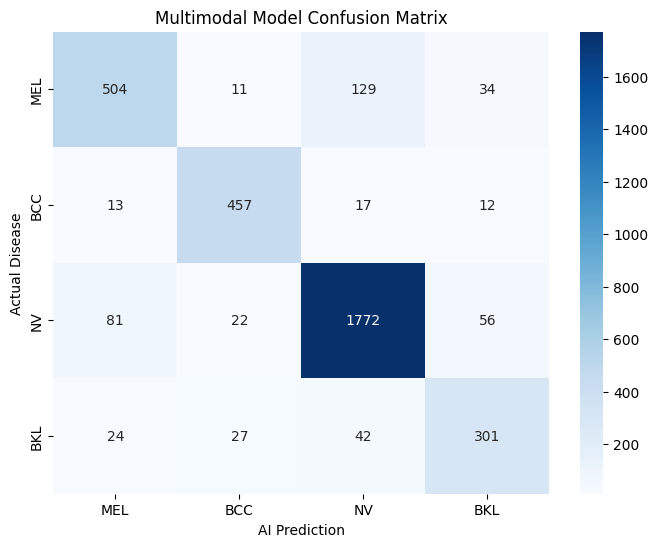

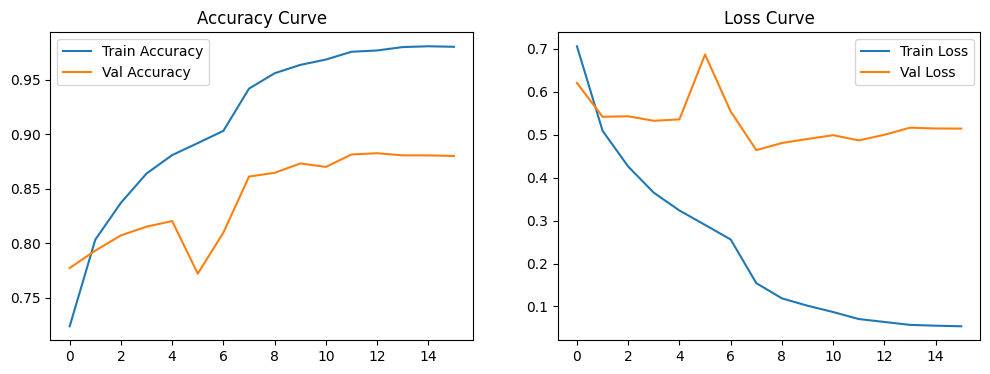

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# 1. Load the BEST model (leaving the overfitted junk behind)
print("Loading the best saved weights...")
best_model = tf.keras.models.load_model("multimodal_efficientnet_best.keras")

# 2. Extract true labels and predict on the Test Set
print("Running predictions on the unseen Test Set...")
# We have to unpack the dictionary from our new tf.data.Dataset
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Print Classification Report
CLASS_NAMES = ['MEL', 'BCC', 'NV', 'BKL']
print("\n--- 📊 FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# 4. Plot Confusion Matrix
print("\n--- 🗺️ CONFUSION MATRIX ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Multimodal Model Confusion Matrix')
plt.ylabel('Actual Disease')
plt.xlabel('AI Prediction')
plt.show()

# 5. Plot Training Curves
# Note: If you manually interrupted, the 'history' variable might not have saved.
# We use a try-except block so the code doesn't crash if it's missing!
try:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Train Accuracy')
    plt.plot(val_acc, label='Val Accuracy')
    plt.legend()
    plt.title('Accuracy Curve')

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend()
    plt.title('Loss Curve')
    plt.show()
except NameError:
    print("\n⚠️ Note: Training curves are unavailable because training was manually interrupted (the 'history' variable wasn't finalized). But your metrics and matrix are accurate!")